### Les installations nécessaires

In [8]:
!pip install plotly


   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --------------------------- ------------ 6.8/9.9 MB 33.5 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 32.2 MB/s  0:00:00


In [ ]:
!conda install -c conda-forge poppler

In [6]:
!pip install embedding_atlas

   ---------------------------------------- 0.0/26.1 MB ? eta -:--:--
   --- ------------------------------------ 2.1/26.1 MB 10.5 MB/s eta 0:00:03
   ------- -------------------------------- 4.7/26.1 MB 11.5 MB/s eta 0:00:02
   ----------- ---------------------------- 7.3/26.1 MB 11.8 MB/s eta 0:00:02
   -------------- ------------------------- 9.4/26.1 MB 11.4 MB/s eta 0:00:02
   ------------------ --------------------- 12.1/26.1 MB 11.4 MB/s eta 0:00:02
   ---------------------- ----------------- 14.4/26.1 MB 11.5 MB/s eta 0:00:02
   -------------------------- ------------- 17.3/26.1 MB 11.6 MB/s eta 0:00:01
   ------------------------------ --------- 19.9/26.1 MB 11.8 MB/s eta 0:00:01
   ---------------------------------- ----- 22.3/26.1 MB 11.6 MB/s eta 0:00:01
   ------------------------------------- -- 24.4/26.1 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 26.1/26.1 MB 11.3 MB/s  0:00:02
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [8]:
!pip install pypdf

In [3]:
!pip install timm

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 18.9 MB/s  0:00:00


In [18]:
!pip install pymupdf

   ---------------------------------------- 0.0/19.2 MB ? eta -:--:--
   -------------- ------------------------- 7.1/19.2 MB 37.1 MB/s eta 0:00:01
   -------------------------------- ------- 15.5/19.2 MB 38.2 MB/s eta 0:00:01
   ---------------------------------------- 19.2/19.2 MB 35.6 MB/s  0:00:00


In [2]:
# c'est pour pouvoir utiliser dinov3 depuis hugging face > il faut faire une requête sur le compte hugging face, il faut attender 2-3h pour être validé mais c'es gratuit et tranquille
from huggingface_hub import login

login()

## Traitement Torquato Tasso

#### Conversition des images pdf en jpg (Torquato Tasso)

In [3]:
from pypdf import PdfReader
from pdf2image import convert_from_path
from PIL import Image
import os
def convert_pdf_to_jpg(input_folder,output_folder, dpi=300, jpeg_quality=75):
    pdf_files = [f for f in os.listdir(input_folder) if f.endswith('.pdf')]
    for pdf_file in pdf_files:
        pdf_path = os.path.join(input_folder, pdf_file)
        pdf_name = os.path.splitext(pdf_file)[0]
        output_file = os.path.join(output_folder, f"{pdf_name}.jpg")
        images = convert_from_path(pdf_path, dpi=dpi)
        images[0].save(output_file, quality=jpeg_quality)

In [4]:
convert_pdf_to_jpg("2. Torquato Tasso/1. Training dataset with images labeled as authentic or fake", "2. Torquato Tasso/datasets/train")

In [21]:
convert_pdf_to_jpg("2. Torquato Tasso/2. Test dataset with unlabeled images", "2. Torquato Tasso/datasets/test")

tasso_000026.pdf -> 1 pages converted
tasso_000027.pdf -> 1 pages converted
tasso_000028.pdf -> 1 pages converted
tasso_000029.pdf -> 1 pages converted
tasso_000030.pdf -> 1 pages converted
tasso_000031.pdf -> 1 pages converted
tasso_000032.pdf -> 1 pages converted
tasso_000033.pdf -> 1 pages converted
tasso_000034.pdf -> 1 pages converted
tasso_000035.pdf -> 1 pages converted
tasso_000036.pdf -> 1 pages converted
tasso_000037.pdf -> 1 pages converted
tasso_000038.pdf -> 1 pages converted
tasso_000041.pdf -> 1 pages converted
tasso_000042.pdf -> 1 pages converted
tasso_000043.pdf -> 1 pages converted
tasso_000044.pdf -> 1 pages converted
tasso_000045.pdf -> 1 pages converted
tasso_000046.pdf -> 1 pages converted
tasso_000047.pdf -> 1 pages converted
tasso_000048.pdf -> 1 pages converted
tasso_000049.pdf -> 1 pages converted
tasso_000050.pdf -> 1 pages converted
tasso_000051.pdf -> 1 pages converted
tasso_000052.pdf -> 1 pages converted
tasso_000053.pdf -> 1 pages converted
tasso_000054

KeyboardInterrupt: 

#### Visualisation des embeddings Torquato Tasso

C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (104175000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


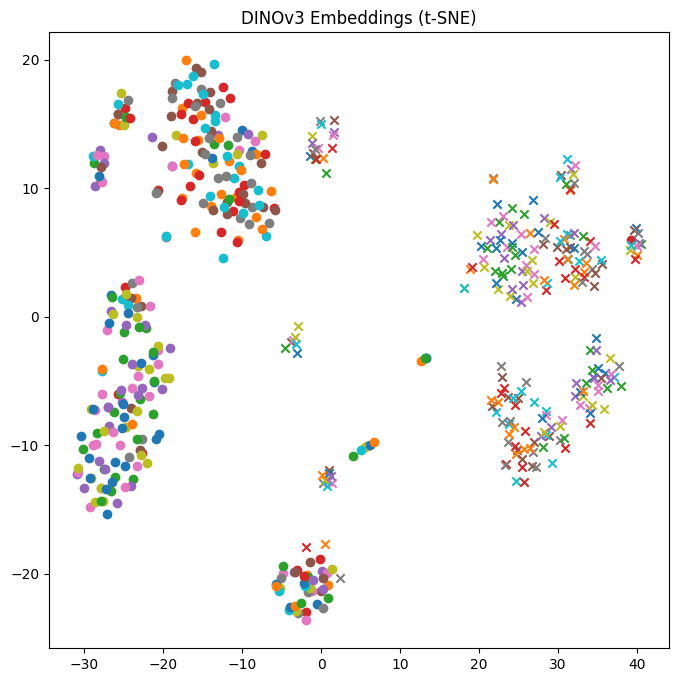

In [1]:
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModel
from sklearn.manifold import TSNE

# Configuration générale
folder = "2. Torquato Tasso/datasets/train"
model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Choix du modèle
processor = AutoImageProcessor.from_pretrained(model_name)
backbone = AutoModel.from_pretrained(model_name).to(device)
backbone.eval()

embeddings_T = []
labels_T = []
names = []

for file in os.listdir(folder):

    if not file.lower().endswith((".jpg", ".png", ".jpeg")): # ne garder que les images
        continue

    path = os.path.join(folder, file)

    img = Image.open(path).convert("RGB")
    img.thumbnail((512, 512))  # important pour pas cramer l'ordi de Côme, redimensionner les images

    inputs = processor(images=img, return_tensors="pt").to(device) # application du modèle pour traiter les images pour les rendre convertibles par Dino

    with torch.no_grad(): # désactiver les calculs de gradiants
        outputs = backbone(**inputs) # conversion des images en embeddings

    emb = outputs.pooler_output.squeeze().cpu().numpy() # on prend les bons outputs

    embeddings_T.append(emb)
    names.append(file)

    # check du nom des images
    if file.startswith("aut"):
        label_T.append(0)
    else:
        labels_T.append(1)

embeddings_T = np.array(embeddings_T)

# réduction des dimensions des embeddings avec TSNE pour les visualiser
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
points = tsne.fit_transform(embeddings_T)

# afficher le résultat 
plt.figure(figsize=(8, 8))

for i in range(len(points)):
    if labels_T[i] == 0:
        plt.scatter(points[i, 0], points[i, 1], marker='o')
    else:
        plt.scatter(points[i, 0], points[i, 1], marker='x')

plt.title("DINOv3 Embeddings (t-SNE)")
plt.show()

display un peu plus clair pour voir les diff entre les classes v

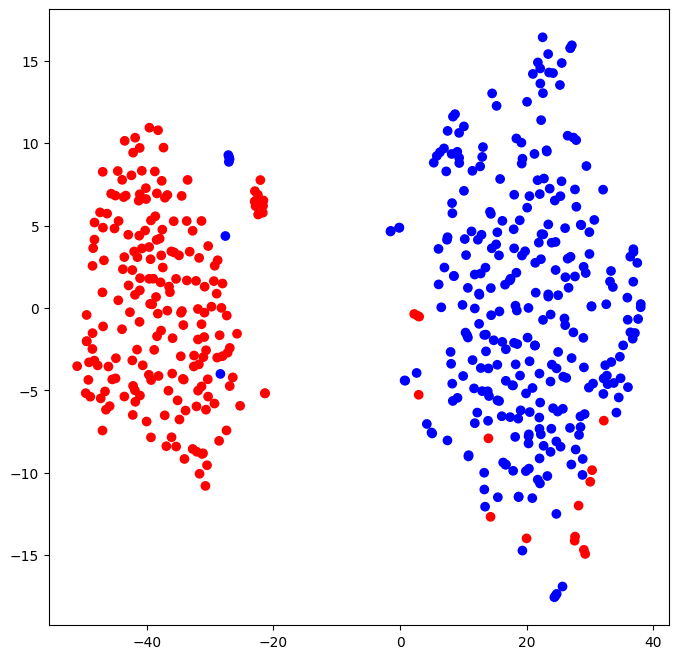

In [5]:
# afficher le résultat mais en mieux
embeddings_T = np.array(embeddings_T)
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
points = tsne.fit_transform(embeddings_T)
plt.figure(figsize=(8, 8))

colors = ["blue" if l == 0 else "red" for l in labels_T] # distinguer le vrai du faux

plt.scatter(points[:, 0], points[:, 1], c=colors)
plt.show()

In [1]:
#substitution d'Atlas 

import plotly.express as px
import pandas as pd

# Définition du dataframe
df = pd.DataFrame({
    "x": points[:, 0],
    "y": points[:, 1],
    "label": ["aut" if l == 0 else "false" for l in labels_P],
    "name": names
})

# configuration du graphique
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="label",
    hover_name="name",
    title="DINOv3 Embeddings (interactive)"
)

fig.show() # affichage

# enregistrement en HTML
fig.write_html("embeddings_Tasso.html")


ModuleNotFoundError: No module named 'plotly'

#### Matrice de confusion

C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\PIL\Image.py:3432: DecompressionBombWarning: Image size (104175000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Embedding shape: (530, 384)


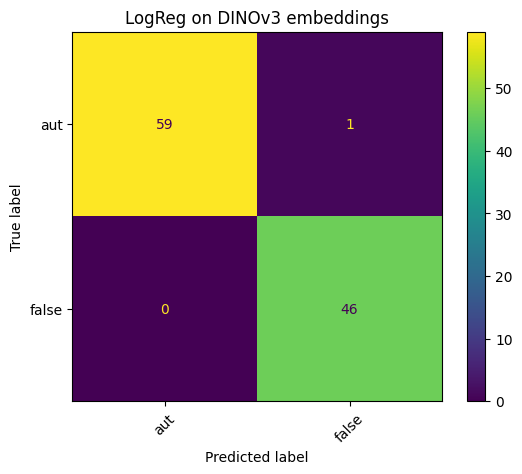

In [11]:
import os
import torch
import numpy as np
from PIL import Image
import pandas as pd
from transformers import AutoImageProcessor, AutoModel

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Configuration
folder = "../2. Torquato Tasso/datasets/train"

model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Choix du modèle
processor = AutoImageProcessor.from_pretrained(model_name)
backbone = AutoModel.from_pretrained(model_name).to(device)
backbone.eval()

embeddings_T = []
labels_T = []

for file in os.listdir(folder):

    if not file.lower().endswith((".jpg", ".jpeg", ".png")): # ne garder que les images
        continue

    path = os.path.join(folder, file)

    img = Image.open(path).convert("RGB") # unformiser les images
    img.thumbnail((512, 512)) # redimensionner les images

    inputs = processor(images=img, return_tensors="pt").to(device) # application du modèle pour traiter les images pour les rendre convertibles par Dino

    with torch.no_grad(): # désactiver les calculs de gradiants
        outputs = backbone(**inputs) # conversion des images en embeddings

    emb = outputs.pooler_output.squeeze().cpu().numpy() # on prend les bons outputs

    embeddings_T.append(emb)
    
    # check du nom des images
    if file.startswith("aut"):
        labels_T.append(0)
    else:
        labels_T.append(1)

# définition des paramètres de l'array
X = np.array(embeddings_T)
y = np.array(labels_T)

print("Embedding shape:", X.shape)

# train, test, split pour entrainer un modèle
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# logisitque régression
clf = LogisticRegression(max_iter=1000)

clf.fit(X_train, y_train)

# prédiction du modèle
y_pred = clf.predict(X_test)

# matrice de confusion
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["aut", "false"])
disp.plot(xticks_rotation=45)

plt.title("LogReg on DINOv3 embeddings")
plt.show()  # afficher la matrice de confusion

In [ ]:
clf.predict()

In [12]:
np.save("embeddings_T_o.npy", embeddings_T)
np.save("laabels_T_o.npy", labels_T)



## Traitement Christine de Pizan

#### Matrice de confusion

Embedding shape: (14848, 384)


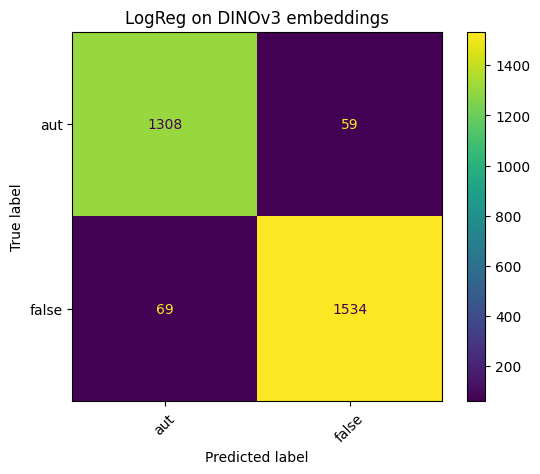

In [2]:
import os
import torch
import numpy as np
from PIL import Image
import pandas as pd
from transformers import AutoImageProcessor, AutoModel

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# configuration 
folder = "ICDAR(1)/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/Pizan_line_train/Pizan_line_train"
#folder = "ICDAR(1)/ICDAR/Christine de Pizan/img_cropped"
csv = "ICDAR(1)/ICDAR/Christine de Pizan/1. Training dataset with images labeled as authentic or fake/Pizan_lines_train.csv"
model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
device = "cuda" if torch.cuda.is_available() else "cpu"

# les labels sont dans un csv pour ce dataset
df = pd.read_csv(csv)

# mapping pour lier les noms des fichiers et les noms dans le csv
label_map = {
    row["filename"]: 0 if row["Pizan"] == "Pizan" else 1
    for _, row in df.iterrows()
}

# choix du modèle
processor = AutoImageProcessor.from_pretrained(model_name)
backbone = AutoModel.from_pretrained(model_name).to(device)
backbone.eval()

embeddings_P = []
labels_P = []

for file in os.listdir(folder):
    if not file.lower().endswith((".jpg", ".jpeg", ".png")): # ne garder que les images
        continue

    path = os.path.join(folder, file)

    img = Image.open(path).convert("RGB")  # unformiser les images
    img.thumbnail((512, 512))  # redimensionner les images

    inputs = processor(images=img, return_tensors="pt").to(device) # application du modèle pour traiter les images pour les rendre convertibles par Dino

    with torch.no_grad():  # désactiver les calculs de gradiants
        outputs = backbone(**inputs) # conversion des images en embeddings

    emb = outputs.pooler_output.squeeze().cpu().numpy() # on prend les bons outputs

    embeddings_P.append(emb)

    # check le nom des labels
    if file not in label_map:
        continue  # skip files not in CSV

    labels_P.append(label_map[file])

# définition des paramètres de l'array
X = np.array(embeddings_P)
y = np.array(labels_P)

print("Embedding shape:", X.shape)

# train,test, split pour entrainer le modèle
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# logistique régression
clf = LogisticRegression(max_iter=1000)

clf.fit(X_train, y_train)

# Prédiction du modèle
y_pred = clf.predict(X_test)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["aut", "false"])
disp.plot(xticks_rotation=45)

plt.title("LogReg on DINOv3 embeddings")
plt.show() # afficher la matrice de confusion

In [7]:
np.save("embeddings_P_o_l.npy", embeddings_P)
np.save("laabels_P_o_l.npy", labels_P)



#### Visualisation des embeddings

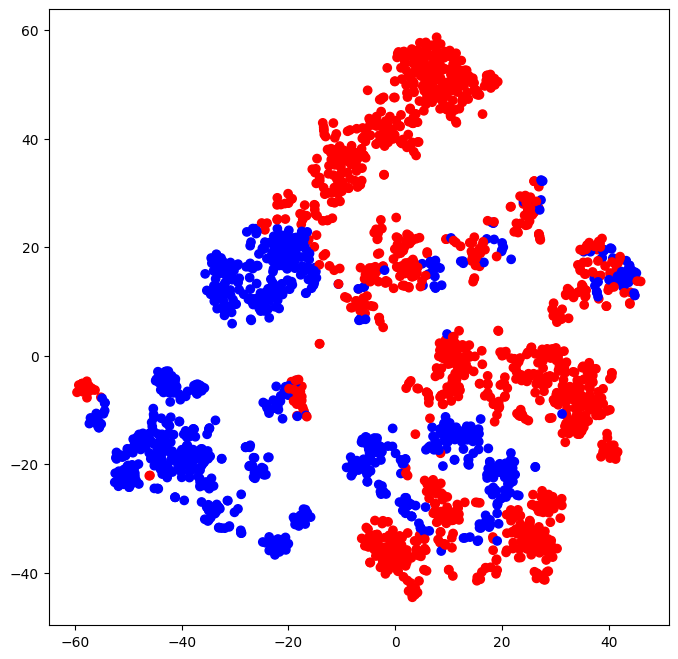

In [3]:
#CELLULE MAGIQUE, ELLE DISPLAY LES EMBEDDINGS EN BLEU ET ROUGE, on réutilise les embeddings et les labels de la matrice plutôt que de tout refaire (comme avec Torquato Tasso)
from sklearn.manifold import TSNE
embeddings_P = np.array(embeddings_P)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
points = tsne.fit_transform(embeddings_P)
plt.figure(figsize=(8, 8))

colors = ["blue" if l == 0 else "red" for l in labels_P]

plt.scatter(points[:, 0], points[:, 1], c=colors)
plt.show()

In [9]:
np.save("embeddings_P_o.npy", embeddings_P)
np.save("laabels_P_o.npy", labels_P)



In [ ]:
#substitution d'Atlas

import plotly.express as px
import pandas as pd

# Définition du dataframe
df = pd.DataFrame({
    "x": points[:, 0],
    "y": points[:, 1],
    "label": ["aut" if l == 0 else "false" for l in labels_P],
    "name": names
})

# configuration du graphique
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="label",
    hover_name="name",
    title="DINOv3 Embeddings (interactive)"
)

fig.show() # affichage

# enregistrement en HTML
fig.write_html("embeddings_Pizan.html")


## Traitement Yaqut Al Musta

#### Matrice de confusion

Embedding shape: (1180, 384)


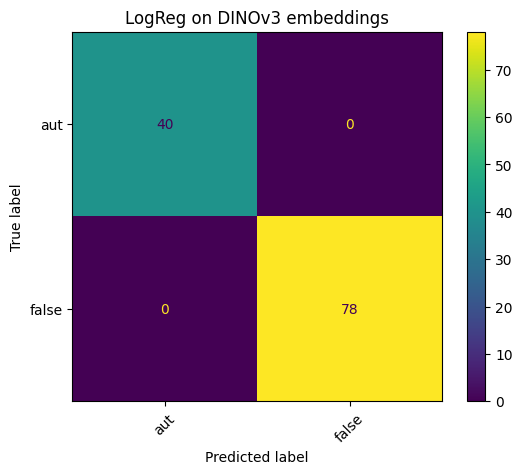

In [25]:
import os
import torch
import numpy as np
from PIL import Image

from transformers import AutoImageProcessor, AutoModel

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# On retrouve ici le même code que pour Torquato Tasso
folder = "ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/1. Training dataset with images labeled as authentic or fake"
#folder = "ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/img_cropped"
#folder = "Downloads/ICDAR(1)/ICDAR/LESTEST"
model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
device = "cuda" if torch.cuda.is_available() else "cpu"

# choix du modèle
processor = AutoImageProcessor.from_pretrained(model_name)
backbone = AutoModel.from_pretrained(model_name).to(device)
backbone.eval()

embeddings_Y = []
labels_Y = []

for file in os.listdir(folder):

    if not file.lower().endswith((".jpg", ".jpeg", ".png")): # ne garder que les images
        continue

    path = os.path.join(folder, file)

    img = Image.open(path).convert("RGB") # uniformiser les images
    img.thumbnail((512, 512)) # redimensionner les images

    inputs = processor(images=img, return_tensors="pt").to(device) # application du modèle pour traiter les images pour les rendre convertibles par Dino

    with torch.no_grad(): # désactiver les calculs de gradiants
        outputs = backbone(**inputs) # conversion des images en embeddings

    emb = outputs.pooler_output.squeeze().cpu().numpy() # on prend les bons outputs

    embeddings_Y.append(emb)

    # check les noms des labels
    if file.startswith("Aut"):
        labels_Y.append(0)
    else:
        labels_Y.append(1)

# paramètres de l'array
X = np.array(embeddings_Y)
y = np.array(labels_Y)

print("Embedding shape:", X.shape)

# train, test, split, entrainement du modèle
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

# logistique régression
clf = LogisticRegression(max_iter=1000)

clf.fit(X_train, y_train)

# prédiction du modèle
y_pred = clf.predict(X_test)

# matrice de confusion
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["aut", "false"])
disp.plot(xticks_rotation=45)

plt.title("LogReg on DINOv3 embeddings")
plt.show() # afficher la matrice de confusion

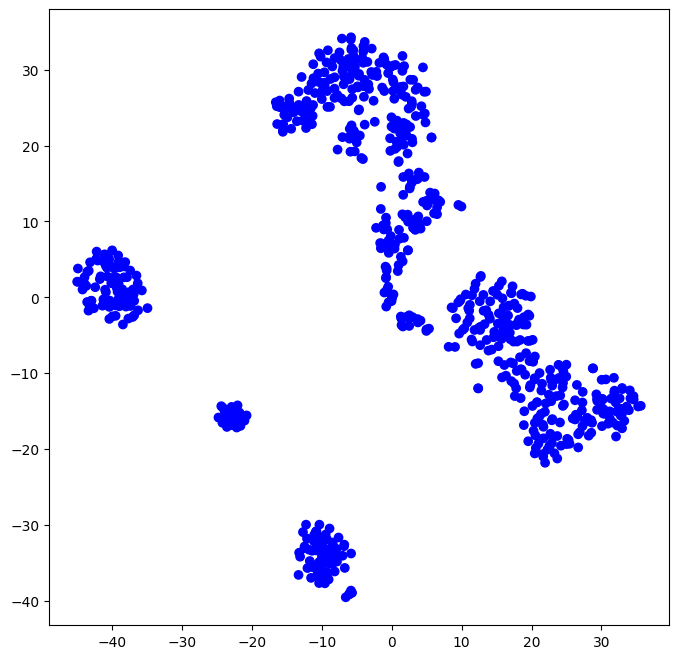

In [17]:
#CELLULE MAGIQUE, ELLE DISPLAY LES EMBEDDINGS EN BLEU ET ROUGE, on réutilise les embeddings et les labels de la matrice plutôt que de tout refaire (comme avec Torquato Tasso)
from sklearn.manifold import TSNE
embeddings_Y = np.array(embeddings_Y)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
points = tsne.fit_transform(embeddings_Y)
plt.figure(figsize=(8, 8))

colors = ["blue" if l == 2 else "red" for l in labels_Y]

plt.scatter(points[:, 0], points[:, 1], c=colors)
plt.show()

In [35]:
aled =np.load("embeddings_Y_t.npy")
prediction =clf.predict(aled)


In [38]:
#np.save("embeddings_Y_t.npy", embeddings_Y)
#np.save("laabels_Y_t.npy", labels_Y)
# récupérer les noms correspondant a chaque embedding
import pandas as pd
def get_names(folder):
        return np.array([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))
        ])
uy =get_names("ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/2. Test dataset with unlabeled images")
df = pd.DataFrame({
    "name": uy,
    "label": [0 if x == 0 else 1 for x in prediction]
})
df.to_csv("outputYAQUT.csv", index=False)
len(uy)
len(prediction)

724

In [20]:
import os
import torch
import numpy as np
from PIL import Image

from transformers import AutoImageProcessor, AutoModel

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# On retrouve ici le même code que pour Torquato Tasso
folder = "ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/1. Training dataset with images labeled as authentic or fake"
#C:\Users\Comep\Downloads\ICDAR(1)\ICDAR\Christine de Pizan\Test dataset with unlabeled images\images_fullpages_test\images_fullpages_test
#folder2 = "C:/Users/Comep/Downloads/ICDAR(1)/ICDAR/Christine de Pizan/Test dataset with unlabeled images/images_fullpages_test/images_fullpages_test"
folder2 = "res/tasso"

#folder2 = "C:/Users/Comep/Downloads/ICDAR(1)/ICDAR/3. Yāqūt al-Mustaʿṣimī/2. Test dataset with unlabeled images"
#folder = "Downloads/ICDAR(1)/ICDAR/LESTEST"µ
model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
device = "cuda" if torch.cuda.is_available() else "cpu"

# choix du modèle
processor = AutoImageProcessor.from_pretrained(model_name)
backbone = AutoModel.from_pretrained(model_name).to(device)
backbone.eval()

embeddings_P = []
labels_P = []

for file in os.listdir(folder2):

    if not file.lower().endswith((".jpg", ".jpeg", ".png")): # ne garder que les images
        continue

    path = os.path.join(folder2, file)

    img = Image.open(path).convert("RGB") # uniformiser les images
    img.thumbnail((512, 512)) # redimensionner les images

    inputs = processor(images=img, return_tensors="pt").to(device) # application du modèle pour traiter les images pour les rendre convertibles par Dino

    with torch.no_grad(): # désactiver les calculs de gradiants
        outputs = backbone(**inputs) # conversion des images en embeddings

    emb = outputs.pooler_output.squeeze().cpu().numpy() # on prend les bons outputs

    embeddings_P.append(emb)

    # check les noms des labels
    
    labels_P.append(2)
    
# paramètres de l'array


In [21]:
len(embeddings_P)

296

In [22]:
np.save("embeddings_P_ExtraSauceDoubleSauce.npy", embeddings_P)
np.save("laabels_P_ExtraSauceDoubleSauce.npy", labels_P)



#### Visualisation des embeddings

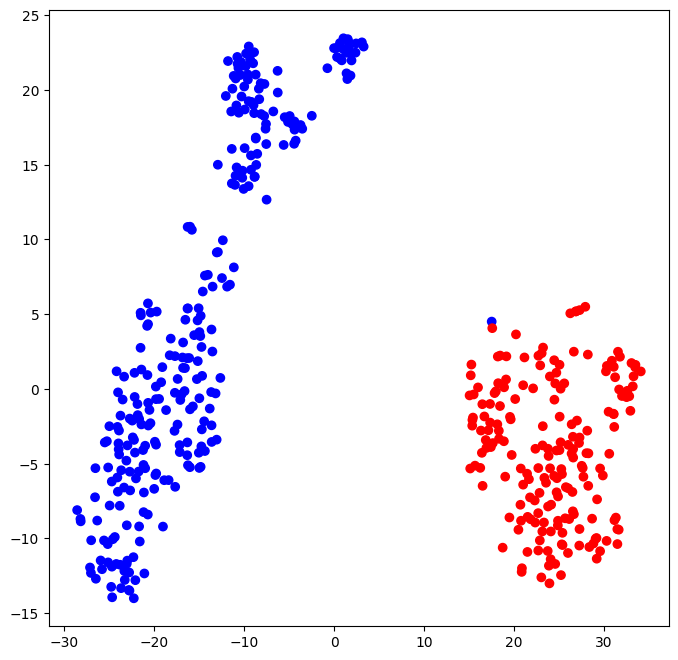

In [9]:
#CELLULE MAGIQUE, ELLE DISPLAY LES EMBEDDINGS EN BLEU ET ROUGE, idem
from sklearn.manifold import TSNE
embeddings_Y = np.array(embeddings_Y)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
points = tsne.fit_transform(embeddings_Y)
plt.figure(figsize=(8, 8))

colors = ["blue" if l == 0 else "red" for l in labels_Y]

plt.scatter(points[:, 0], points[:, 1], c=colors)
plt.show()

In [5]:
#CELLULE MAGIQUE, ELLE DISPLAY LES EMBEDDINGS EN BLEU ET ROUGE, idem
from sklearn.manifold import TSNE
embeddings_Y = np.array(embeddings_Y)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
points = tsne.fit_transform(embeddings_Y)
plt.figure(figsize=(8, 8))

colors = ["blue" if l == 0 for l in labels_Y else "red" if l ==1  for l in labels_Y else  "yellow"]

plt.scatter(points[:, 0], points[:, 1], c=colors)
plt.show()

SyntaxError: expected 'else' after 'if' expression (1351295765.py, line 9)

In [ ]:
#substitution d'Atlas 

import plotly.express as px
import pandas as pd

# Définition du dataframe
df = pd.DataFrame({
    "x": points[:, 0],
    "y": points[:, 1],
    "label": ["aut" if l == 0 else "false" for l in labels_Y],
    "name": names
})

# Configuration du graphique
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="label",
    hover_name="name",
    title="DINOv3 Embeddings (interactive)"
)

fig.show() # affichage

# enregistrement en HTML
fig.write_html("embeddings_AlMusta.html")


## Calculs

#### Le top-k retrieval accurary

In [20]:
def topk_retrieval_accuraccy(X, y, k=1):
    """
    X: embeddings (N, D)
    y: labels (N,)
    k: number of neighbors
    """
    
    #calcule de la distance cosine entre les embeddings X
    D = cosine_distances(X)
    
    N = len(y) # tous les labels qu'on a (qui correspondent à tous les "points")
    correct = 0

    for i in range(N):
        #exclusion de l'embedding avec lui-même
        D[i, i] = np.inf

        #trouver les k voisins
        nn_idx = np.argsort(D[i])[:k]

        #vérifier les labels des k voisins
        if np.any(y[nn_idx] == y[i]):
            correct += 1
    #calcul du ratio de nombre de voisins par rapport au nombre de points total
    return correct / N

In [21]:
topk_retrieval_accuraccy(X,y,1)

0.9905660377358491

In [18]:
import os
import torch
import numpy as np
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import top_k_accuracy_score

xx= top_k_accuracy_score(y_test,y_pred,k=1)

In [19]:
xx

0.9905660377358491

#### Les similarités euclidiennes et distances cosines

In [22]:
import numpy as np
import torch
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

def similarite(embeddings):
    names = list(embeddings.keys())
    vectors = torch.stack([
        embeddings[name] for name in names
    ]).cpu().numpy()

    cos = cosine_similarity(vectors)
    eucl = euclidean_distances(vectors)

    return names, cos, eucl

In [1]:
similarite(e)

NameError: name 'similarite' is not defined

In [24]:
#Similarité cosine et prédiction des images les plus proches

import os
import torch
import numpy as np
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

def embed_and_compare(folder, backbone, processor, device="cuda"):

    backbone.eval() # inférence

    lab = []
    embed = []

    for file in os.listdir(folder):

        if not file.lower().endswith((".jpg",".jpeg",".png")): # ne garder que les images
            continue

        path = os.path.join(folder, file)

        img = Image.open(path).convert("RGB") #unformisation des images

        inputs = processor(images=img, return_tensors="pt").to(device) # application du modèle pour traiter les images pour les rendre convertibles par Dino

        with torch.no_grad : #désactiver les calculs de gradiants
            outputs = backbone(**inputs) # conversion des images en embeddings

        emb = outputs.pooler_output.squeeze().cpu() # on prend les bons outputs

        lab.append(file)
        embed.append(emb)

    embed = torch.stack(embed).numpy() # conversion des embeddings en objet numpy

    cos = cosine_similarity(embed) # calcul de la similarité cosine sur les embeddings

    for i in range(len(lab)):

        scores = cos[i]

        idx = np.argsort(-scores) # tri décroissant en prenant les images les plus similaires en premier

        print("\nQuery:", lab[i]) # afficher le nom de l'image de référence

        for j in idx[1:6]: # sélection des 5 images les plus proches
            print("  ", lab[j], "score:", float(scores[j]))

    return lab, embed, cos

In [26]:
lab, embed, cos = embed_and_compare(
    "2. Torquato Tasso/datasets/train",
    backbone,
    processor,
    device
)


Query: aut_0001.jpg
   aut_0018.jpg score: 0.9796944260597229
   aut_0023.jpg score: 0.973733127117157
   aut_0020.jpg score: 0.973135769367218
   aut_0016.jpg score: 0.9729202389717102
   aut_0034.jpg score: 0.9726810455322266

Query: aut_0002.jpg
   aut_0025.jpg score: 0.9789097905158997
   aut_0024.jpg score: 0.9726517796516418
   aut_0001.jpg score: 0.9723448753356934
   aut_0016.jpg score: 0.9718768000602722
   aut_0033.jpg score: 0.971551239490509

Query: aut_0003.jpg
   aut_0038.jpg score: 0.9745612144470215
   aut_0025.jpg score: 0.9651980400085449
   aut_0021.jpg score: 0.9626168608665466
   aut_0001.jpg score: 0.9624797105789185
   aut_0013.jpg score: 0.9622592926025391

Query: aut_00035.jpg
   aut_0027.jpg score: 0.9793737530708313
   aut_0018.jpg score: 0.9755873084068298
   aut_0019.jpg score: 0.9741216897964478
   aut_0020.jpg score: 0.9739106297492981
   aut_0013.jpg score: 0.9738446474075317

Query: aut_0004.jpg
   aut_0024.jpg score: 0.9661340117454529
   aut_0022.jpg

## Configuration Atlas

In [6]:
#Export Atlas pour visualiser les données, nécessite une matipulation d'un terminal
import os
import pandas as pd
import numpy as np
import umap.umap_ as umap

print(" Building UMAP projection...")

# configuration de la UMAP
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)
X=embeddings # /!\ attention à renommer les embeddings : embeddings_T, embeddings_P, embeddings_Y
y=label # /!\ attention à renomer les labels : labels_T, labels_P, labels_Y
X_2d = reducer.fit_transform(X)

# Paramètres du Dataframe
df = pd.DataFrame({
    "embedding": list(X),
    "umap_x": X_2d[:, 0],
    "umap_y": X_2d[:, 1],
    "label": y,
    "filename": filenames if "filenames" in globals() else [f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))] # on ne garde que les images
})

# unfirmisation des chemins d'accès (sous Windows)
df["image_path"] = [os.path.join(folder, f).replace("\\", "/") for f in df["filename"]]

# --- Nice labels ---
df["label_name"] = df["label"].map({ 
    0: "authentic",
    1: "fake"
})

# enregistrement du .parquet
output_file = "atlas_dataset.parquet"
df.to_parquet(output_file, index=False)

print(f"File saved as: {output_file}")
print("Next step: run Atlas in a terminal with 'embedding-atlas atlas_dataset.parquet --x umap_x --y umap_y'.")

🚀 Building UMAP projection...


C:\Users\Comep\miniconda3\envs\niou\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ DONE. File saved as: atlas_dataset.parquet
👉 Next step: run Atlas in your terminal


In [6]:
import os
import shutil
import re

# Paths
f1 = "tasso_000330-1-298-pages-1"
f2 = "tasso_000330-1-298-pages-2"
f3 = "tasso_000330-1-298-pages-3"
output = "outiput"

os.makedirs(output, exist_ok=True)

counter = 1

# --- Helper to extract number after "_" ---
def extract_number_f1(filename):
    match = re.search(r'_(\d+)', filename)
    return int(match.group(1)) if match else 0

# --- Process folder 1 ---
files_f1 = sorted(os.listdir(f1), key=extract_number_f1)

for file in files_f1:
    src = os.path.join(f1, file)
    dst = os.path.join(output, f"tasso_000330_{counter}.jpg")
    shutil.copy(src, dst)
    counter += 1

# --- Helper for simple numeric filenames ---
def extract_number_simple(filename):
    return int(os.path.splitext(filename)[0])

# --- Process folder 2 ---
files_f2 = sorted(os.listdir(f2), key=extract_number_simple)

for file in files_f2:
    src = os.path.join(f2, file)
    dst = os.path.join(output, f"tasso_000330_{counter}.jpg")
    shutil.copy(src, dst)
    counter += 1

# --- Process folder 3 ---
files_f3 = sorted(os.listdir(f3), key=extract_number_simple)

for file in files_f3:
    src = os.path.join(f3, file)
    dst = os.path.join(output, f"tasso_000330_{counter}.jpg")
    shutil.copy(src, dst)
    counter += 1

print("Done! Total images:", counter - 1)

Done! Total images: 298
